In [10]:
# Cell 1: Mount Drive & Verify Path
from google.colab import drive
import os

# 1. Mount Drive (Click 'Allow' in the popup)
drive.mount('/content/drive')

# 2. Define your dataset path
# NOTE: Make sure this matches your folder exactly (e.g., 'DataSet' vs 'dataset')
base_path = '/content/drive/MyDrive/DataSet'

# 3. Check if it exists
if os.path.exists(base_path):
    print(f"\n✅ SUCCESS: Found dataset at: {base_path}")

    # Check for 'train' and 'valid' folders
    contents = os.listdir(base_path)
    if 'train' in contents and 'valid' in contents:
        print(f"✅ Structure correct: Found 'train' and 'valid' inside.")
        train_dir = os.path.join(base_path, 'train')
        valid_dir = os.path.join(base_path, 'valid')
    else:
        print(f"❌ ERROR: Could not find 'train' or 'valid' folders. Found: {contents}")
else:
    print(f"\n❌ ERROR: Path not found: {base_path}")
    print("Check capital letters! 'DataSet' is different from 'dataset'.")

Mounted at /content/drive

✅ SUCCESS: Found dataset at: /content/drive/MyDrive/DataSet
✅ Structure correct: Found 'train' and 'valid' inside.


In [11]:
# Cell 2: Imports & Preprocessing Class
import cv2
import numpy as np
import tensorflow as tf
from tensorflow.keras import layers, models, applications
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input
import matplotlib.pyplot as plt

class TonguePreprocessor:
    def __init__(self, target_size=(224, 224)):
        self.target_size = target_size

    def process_image(self, img):
        # Convert RGB (from Keras) to BGR (for OpenCV)
        img = np.array(img).astype('uint8')
        img = cv2.cvtColor(img, cv2.COLOR_RGB2BGR)

        # 1. Color Balance
        lab = cv2.cvtColor(img, cv2.COLOR_BGR2LAB)
        avg_a = np.average(lab[:, :, 1])
        avg_b = np.average(lab[:, :, 2])
        lab[:, :, 1] = lab[:, :, 1] - ((avg_a - 128) * (lab[:, :, 0] / 255.0) * 1.1)
        lab[:, :, 2] = lab[:, :, 2] - ((avg_b - 128) * (lab[:, :, 0] / 255.0) * 1.1)
        img = cv2.cvtColor(lab, cv2.COLOR_LAB2BGR)

        # 2. Segmentation (Isolate Tongue)
        hsv = cv2.cvtColor(img, cv2.COLOR_BGR2HSV)
        # Combine two red ranges for better coverage
        lower1, upper1 = np.array([0, 40, 50]), np.array([20, 255, 255])
        lower2, upper2 = np.array([160, 40, 50]), np.array([180, 255, 255])
        mask = cv2.inRange(hsv, lower1, upper1) + cv2.inRange(hsv, lower2, upper2)

        # Clean noise
        mask = cv2.morphologyEx(mask, cv2.MORPH_OPEN, np.ones((5,5), np.uint8))

        # Crop
        contours, _ = cv2.findContours(mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
        if contours:
            c = max(contours, key=cv2.contourArea)
            x, y, w, h = cv2.boundingRect(c)
            # Add padding
            x = max(0, x-20); y = max(0, y-20)
            img = img[y:y+h+40, x:x+w+40]
        else:
            # Center crop fallback
            h, w = img.shape[:2]
            c_h, c_w = h//2, w//2
            s = min(h, w)//2
            img = img[c_h-s:c_h+s, c_w-s:c_w+s]

        # Resize and return to MobileNet format
        img = cv2.resize(img, self.target_size)
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        return preprocess_input(img.astype('float32'))

In [38]:
# Cell 3 (Upgraded): Preprocessing with Shadow Removal
class TonguePreprocessor:
    def __init__(self, target_size=(224, 224)):
        self.target_size = target_size

    def remove_shadows(self, img):
        # Convert to LAB color space
        lab = cv2.cvtColor(img, cv2.COLOR_BGR2LAB)
        l, a, b = cv2.split(lab)

        # Apply CLAHE to the L-channel (Lightness)
        # This equalizes the light distribution, killing shadows
        clahe = cv2.createCLAHE(clipLimit=3.0, tileGridSize=(8,8))
        cl = clahe.apply(l)

        # Merge back
        limg = cv2.merge((cl, a, b))
        return cv2.cvtColor(limg, cv2.COLOR_LAB2BGR)

    def process_image(self, img):
        # Convert RGB (Keras) to BGR (OpenCV)
        img = np.array(img).astype('uint8')
        img = cv2.cvtColor(img, cv2.COLOR_RGB2BGR)

        # --- STEP 1: SHADOW REMOVAL (NEW!) ---
        img = self.remove_shadows(img)

        # --- STEP 2: Color Balance (Gray World) ---
        # (We keep this to fix yellow/blue tints)
        lab = cv2.cvtColor(img, cv2.COLOR_BGR2LAB)
        avg_a = np.average(lab[:, :, 1])
        avg_b = np.average(lab[:, :, 2])
        lab[:, :, 1] = lab[:, :, 1] - ((avg_a - 128) * (lab[:, :, 0] / 255.0) * 1.1)
        lab[:, :, 2] = lab[:, :, 2] - ((avg_b - 128) * (lab[:, :, 0] / 255.0) * 1.1)
        img = cv2.cvtColor(lab, cv2.COLOR_LAB2BGR)

        # --- STEP 3: Segmentation ---
        hsv = cv2.cvtColor(img, cv2.COLOR_BGR2HSV)
        lower1 = np.array([0, 40, 50]); upper1 = np.array([20, 255, 255])
        lower2 = np.array([160, 40, 50]); upper2 = np.array([180, 255, 255])
        mask = cv2.inRange(hsv, lower1, upper1) + cv2.inRange(hsv, lower2, upper2)
        mask = cv2.morphologyEx(mask, cv2.MORPH_OPEN, np.ones((5,5), np.uint8))

        contours, _ = cv2.findContours(mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

        if contours:
            c = max(contours, key=cv2.contourArea)
            x, y, w, h = cv2.boundingRect(c)
            # Tighter crop to avoid background shadows
            x = max(0, x-10); y = max(0, y-10)
            img = img[y:y+h+20, x:x+w+20]

        img = cv2.resize(img, self.target_size)
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        return preprocess_input(img.astype('float32'))

# Re-Initialize
processor = TonguePreprocessor(target_size=(224, 224))
print("✅ Shadow Removal Engine Loaded.")

✅ Shadow Removal Engine Loaded.


In [39]:
# Cell 4: Data Generators (Fixed)
BATCH_SIZE = 32
IMG_SIZE = (224, 224)

# 1. Training Generator
# Cell 4 (Upgraded): Data Generator with Brightness Jitter
train_datagen = ImageDataGenerator(
    preprocessing_function=processor.process_image,
    rotation_range=20,
    width_shift_range=0.1,
    height_shift_range=0.1,
    zoom_range=0.2,
    horizontal_flip=True,

    # --- NEW ADDITION ---
    brightness_range=[0.5, 1.5] # Randomly darken/brighten images
)

# 2. Validation Generator
valid_datagen = ImageDataGenerator(
    preprocessing_function=processor.process_image # <--- Matches the new name
)

print("--- Loading Training Data ---")
train_generator = train_datagen.flow_from_directory(
    train_dir,  # Make sure Cell 1 was run so this variable exists!
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='binary',
    shuffle=True
)

print("\n--- Loading Validation Data ---")
valid_generator = valid_datagen.flow_from_directory(
    valid_dir,  # Make sure Cell 1 was run so this variable exists!
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='binary',
    shuffle=False
)

print(f"\n✅ Class Indices: {train_generator.class_indices}")

--- Loading Training Data ---
Found 2100 images belonging to 2 classes.

--- Loading Validation Data ---
Found 600 images belonging to 2 classes.

✅ Class Indices: {'diabetes': 0, 'nondiabetes': 1}


In [40]:
# Cell 5: Build Model
# Load the base model (MobileNetV2) without the top layer
base_model = applications.MobileNetV2(
    input_shape=(224, 224, 3), # Must match our image size
    include_top=False,
    weights='imagenet'
)

# Freeze the base model
# This prevents the AI from "forgetting" basic shapes/edges it already knows
base_model.trainable = False

# Add our custom layers
x = base_model.output
x = layers.GlobalAveragePooling2D()(x)
x = layers.Dropout(0.4)(x)  # Drop 40% of connections to prevent overfitting
x = layers.Dense(128, activation='relu')(x)
output = layers.Dense(1, activation='sigmoid')(x) # Sigmoid for Binary (0 or 1)

# Combine them
model = models.Model(inputs=base_model.input, outputs=output)

# Compile the model
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.0001), # Low learning rate for fine-tuning
    loss='binary_crossentropy',
    metrics=['accuracy']
)

model.summary()
print("\n✅ Model built successfully. Ready to train!")

Model: "functional_10"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1       │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1 (Conv2D)      │ (None, 112, 112,  │        864 │ input_layer_1[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bn_Conv1            │ (None, 112, 112,  │        128 │ Conv1[0][0]       │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1_relu (ReLU)   │ (None, 112, 112,  │          0 │ bn_Conv1[0][0]    │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │        288 │ Conv1_relu[0][0]  │
│ (DepthwiseConv2D)   │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │        128 │ expanded_conv_de… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │          0 │ expanded_conv_de… │
│ (ReLU)              │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 112, 112,  │        512 │ expanded_conv_de… │
│ (Conv2D)            │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 112, 112,  │         64 │ expanded_conv_pr… │
│ (BatchNormalizatio… │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand      │ (None, 112, 112,  │      1,536 │ expanded_conv_pr… │
│ (Conv2D)            │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_BN   │ (None, 112, 112,  │        384 │ block_1_expand[0… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_relu │ (None, 112, 112,  │          0 │ block_1_expand_B… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_pad         │ (None, 113, 113,  │          0 │ block_1_expand_r… │
│ (ZeroPadding2D)     │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise   │ (None, 56, 56,    │        864 │ block_1_pad[0][0] │
│ (DepthwiseConv2D)   │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 56, 56,    │        384 │ block_1_depthwis… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 56, 56,    │          0 │ block_1_depthwis… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_project     │ (None, 56, 56,    │      2,304 │ block_1_depthwis

 Total params: 2,422,081 (9.24 MB)

 Trainable params: 164,097 (641.00 KB)

 Non-trainable params: 2,257,984 (8.61 MB)


✅ Model built successfully. Ready to train!


Starting Training... (10 Epochs)
Epoch 1/10
66/66 ━━━━━━━━━━━━━━━━━━━━ 0s 704ms/step - accuracy: 0.5334 - loss: 0.7582
Epoch 1: val_accuracy improved from -inf to 0.69500, saving model to /content/drive/MyDrive/best_diabetes_model.keras
66/66 ━━━━━━━━━━━━━━━━━━━━ 67s 917ms/step - accuracy: 0.5341 - loss: 0.7574 - val_accuracy: 0.6950 - val_loss: 0.5721
Epoch 2/10
66/66 ━━━━━━━━━━━━━━━━━━━━ 0s 646ms/step - accuracy: 0.6921 - loss: 0.5784
Epoch 2: val_accuracy improved from 0.69500 to 0.72500, saving model to /content/drive/MyDrive/best_diabetes_model.keras
66/66 ━━━━━━━━━━━━━━━━━━━━ 48s 723ms/step - accuracy: 0.6925 - loss: 0.5782 - val_accuracy: 0.7250 - val_loss: 0.5487
Epoch 3/10
66/66 ━━━━━━━━━━━━━━━━━━━━ 0s 644ms/step - accuracy: 0.7309 - loss: 0.5340
Epoch 3: val_accuracy improved from 0.72500 to 0.73500, saving model to /content/drive/MyDrive/best_diabetes_model.keras
66/66 ━━━━━━━━━━━━━━━━━━━━ 49s 738ms/step - accuracy: 0.7308 - loss: 0.5342 - val_accuracy: 0.7350 - val_loss: 0.

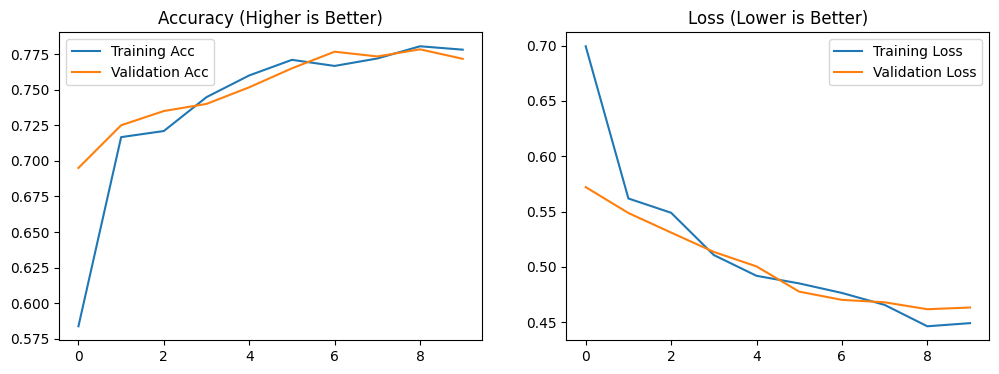

In [42]:
# Cell 6: Train (10 Epochs)
# Define where to save the best model
checkpoint_path = '/content/drive/MyDrive/best_diabetes_model.keras'

callbacks = [
    # Save the model ONLY if it gets better validation accuracy
    tf.keras.callbacks.ModelCheckpoint(
        checkpoint_path,
        save_best_only=True,
        monitor='val_accuracy',
        verbose=1
    ),
    # Stop training if accuracy stops improving after 5 epochs (saves time)
    tf.keras.callbacks.EarlyStopping(
        monitor='val_loss',
        patience=5,
        restore_best_weights=True
    )
]

print("Starting Training... (10 Epochs)")

history = model.fit(
    train_generator,
    epochs=10,  # <--- CHANGED TO 10
    validation_data=valid_generator,
    callbacks=callbacks
)

# --- Visualize Results ---
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']
loss = history.history['loss']
val_loss = history.history['val_loss']

plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(acc, label='Training Acc')
plt.plot(val_acc, label='Validation Acc')
plt.title('Accuracy (Higher is Better)')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(loss, label='Training Loss')
plt.plot(val_loss, label='Validation Loss')
plt.title('Loss (Lower is Better)')
plt.legend()
plt.show()

/usr/local/lib/python3.12/dist-packages/keras/src/models/functional.py:241: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: [['input_layer_1']]
Received: inputs=Tensor(shape=(1, 224, 224, 3))
  warnings.warn(msg)
/tmp/ipython-input-638539799.py:75: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  jet = cm.get_cmap("jet")


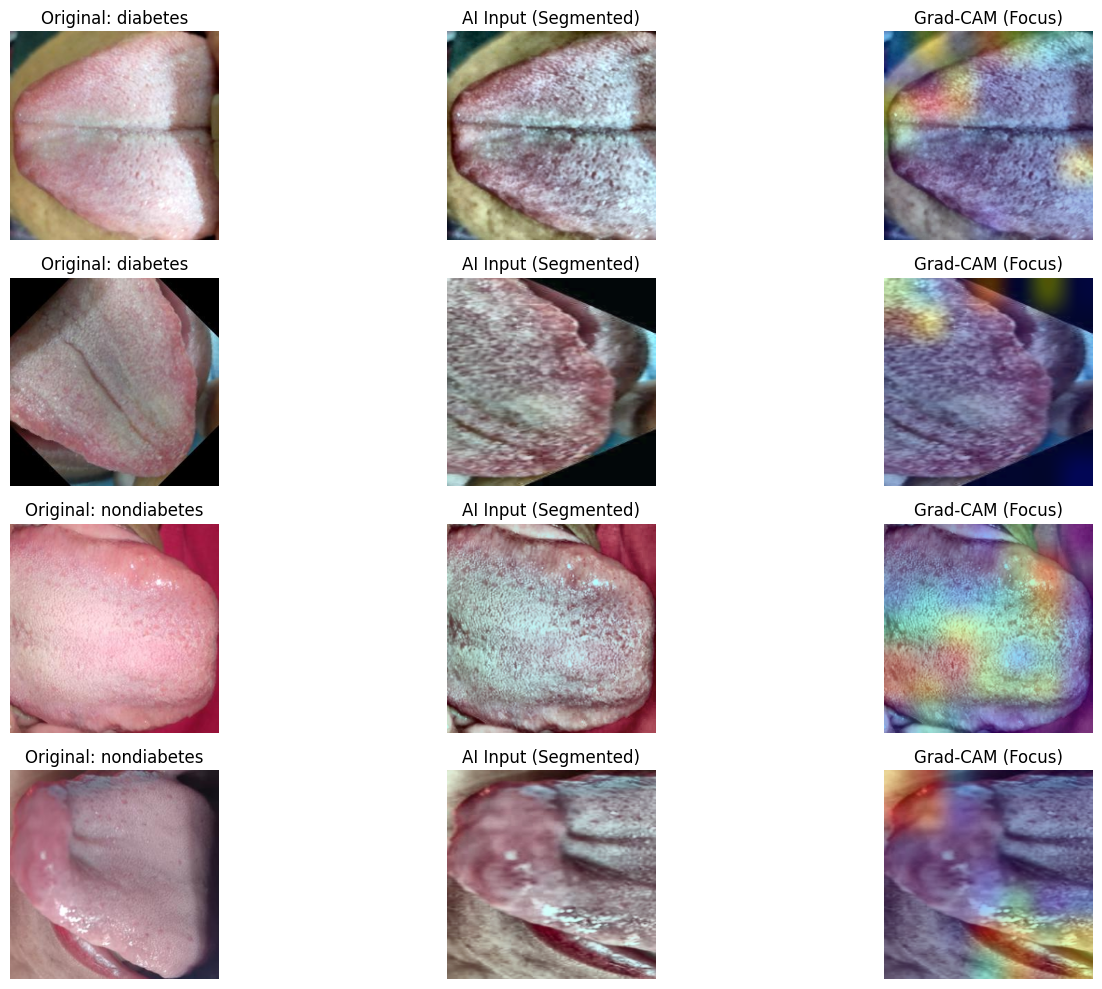

In [43]:
# Cell 8: Auto-Visualize Training Samples
import random
import matplotlib.cm as cm

# 1. Define Grad-CAM Logic (Standard Keras Implementation)
def make_heatmap(img_array, model, last_conv_layer_name="out_relu"):
    # Create a model that outputs the last conv layer + the final prediction
    grad_model = tf.keras.models.Model(
        [model.inputs],
        [model.get_layer(last_conv_layer_name).output, model.output]
    )

    # Record operations for gradient calculation
    with tf.GradientTape() as tape:
        last_conv_layer_output, preds = grad_model(img_array)
        class_channel = preds[:, 0] # We look at the output neuron

    # Calculate gradients
    grads = tape.gradient(class_channel, last_conv_layer_output)
    pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))

    # Multiply feature map by importance
    last_conv_layer_output = last_conv_layer_output[0]
    heatmap = last_conv_layer_output @ pooled_grads[..., tf.newaxis]
    heatmap = tf.squeeze(heatmap)

    # Normalize
    heatmap = tf.maximum(heatmap, 0) / tf.math.reduce_max(heatmap)
    return heatmap.numpy()

def show_training_examples():
    # Load Model
    model = tf.keras.models.load_model('/content/drive/MyDrive/best_diabetes_model.keras')
    processor = TonguePreprocessor() # Use our custom class

    # Define paths
    base_dir = '/content/drive/MyDrive/DataSet/train'
    classes = ['diabetes', 'nondiabetes'] # Make sure these match your folder names!

    # Setup the plot
    plt.figure(figsize=(15, 10))
    plot_idx = 1

    for category in classes:
        # Get random images from folder
        folder_path = os.path.join(base_dir, category)
        if not os.path.exists(folder_path):
            print(f"Skipping {category} - Folder not found.")
            continue

        all_images = os.listdir(folder_path)
        # Pick 2 random images
        selected_images = random.sample(all_images, 2)

        for img_name in selected_images:
            img_path = os.path.join(folder_path, img_name)

            # --- Process ---
            # 1. Read
            original = cv2.imread(img_path)
            if original is None: continue
            original_rgb = cv2.cvtColor(original, cv2.COLOR_BGR2RGB)

            # 2. Preprocess (Color + Segment)
            processed = processor.process_image(original_rgb) # Use the FIXED function name
            img_array = np.expand_dims(processed, axis=0)

            # 3. Generate Heatmap
            # 'out_relu' is the last convolutional layer in MobileNetV2
            heatmap = make_heatmap(img_array, model, "out_relu")

            # 4. Create Overlay
            # Resize heatmap to 224x224
            heatmap = np.uint8(255 * heatmap)
            jet = cm.get_cmap("jet")
            jet_colors = jet(np.arange(256))[:, :3]
            jet_heatmap = jet_colors[heatmap]

            jet_heatmap = tf.keras.preprocessing.image.array_to_img(jet_heatmap)
            jet_heatmap = jet_heatmap.resize((224, 224))
            jet_heatmap = tf.keras.preprocessing.image.img_to_array(jet_heatmap)

            # Rescale processed image back to 0-255 for display
            display_img = (processed + 1) * 127.5

            # Superimpose
            superimposed = jet_heatmap * 0.4 + display_img
            superimposed = tf.keras.preprocessing.image.array_to_img(superimposed)

            # --- Plotting ---
            # Show Original
            plt.subplot(4, 3, plot_idx)
            plt.imshow(original_rgb)
            plt.title(f"Original: {category}")
            plt.axis('off')
            plot_idx += 1

            # Show AI View (Segmented)
            plt.subplot(4, 3, plot_idx)
            plt.imshow(tf.keras.preprocessing.image.array_to_img(display_img))
            plt.title("AI Input (Segmented)")
            plt.axis('off')
            plot_idx += 1

            # Show Heatmap
            plt.subplot(4, 3, plot_idx)
            plt.imshow(superimposed)
            plt.title("Grad-CAM (Focus)")
            plt.axis('off')
            plot_idx += 1

    plt.tight_layout()
    plt.show()

# Run it
show_training_examples()

In [1]:
# Cell 7: Real-World Prediction
import numpy as np
from tensorflow.keras.preprocessing.image import load_img, img_to_array

def predict_diabetes_risk(image_path):
    # 1. Check if file exists
    if not os.path.exists(image_path):
        print(f"❌ Error: Image not found at {image_path}")
        return

    # 2. Load the best saved model
    # Note: We use the .keras file we saved in the callback
    model_path = '/content/drive/MyDrive/best_diabetes_model.keras'
    if not os.path.exists(model_path):
        print("❌ Error: Model file not found. Did Cell 6 finish training?")
        return

    print("Loading model...")
    loaded_model = models.load_model(model_path)

    # 3. Preprocess the image (EXACTLY like we did for training)
    # We use OpenCV to read it so we can use our custom processor
    img = cv2.imread(image_path)
    if img is None:
        print("❌ Error: Could not read image file.")
        return

    # Convert BGR to RGB
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    # Use our custom class
    proc = TonguePreprocessor(target_size=(224, 224))
    processed_img = proc.process_image(img_rgb)

    # Add the "batch" dimension (1, 224, 224, 3) because AI expects a list of images
    input_tensor = np.expand_dims(processed_img, axis=0)

    # 4. Predict
    print("Analyzing tongue features...")
    prediction = loaded_model.predict(input_tensor)[0][0]

    # 5. Interpret Result
    # Get the class names from the generator
    # usually {'Diabetic': 1, 'Non-Diabetic': 0} or similar
    class_map = train_generator.class_indices
    # Flip it to get Name from Number
    label_map = {v: k for k, v in class_map.items()}

    # The model outputs a number between 0 and 1.
    # > 0.5 usually means the class labeled "1"
    if prediction > 0.5:
        result = label_map[1]
        confidence = prediction
    else:
        result = label_map[0]
        confidence = 1 - prediction

    # 6. Show Result
    plt.figure(figsize=(8, 8))
    plt.imshow(img_rgb)
    plt.axis('off')

    color = 'red' if 'Diabetic' in result else 'green'
    plt.title(f"Diagnosis: {result}\nConfidence: {confidence:.2%}", color=color, fontsize=16, fontweight='bold')
    plt.show()

# === RUN THE TEST ===
# Replace this path with the path to your uploaded image
test_image_path = '/content/drive/MyDrive/DataSet/RealTest/joe2.jpeg'

# Run the function
predict_diabetes_risk(test_image_path)

ModuleNotFoundError: No module named 'numpy'


🔎 Result: Diabetic
📊 Raw Score: 0.3147 (0=Diabetic, 1=Healthy)


/tmp/ipython-input-2360288714.py:81: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  jet = cm.get_cmap("jet")


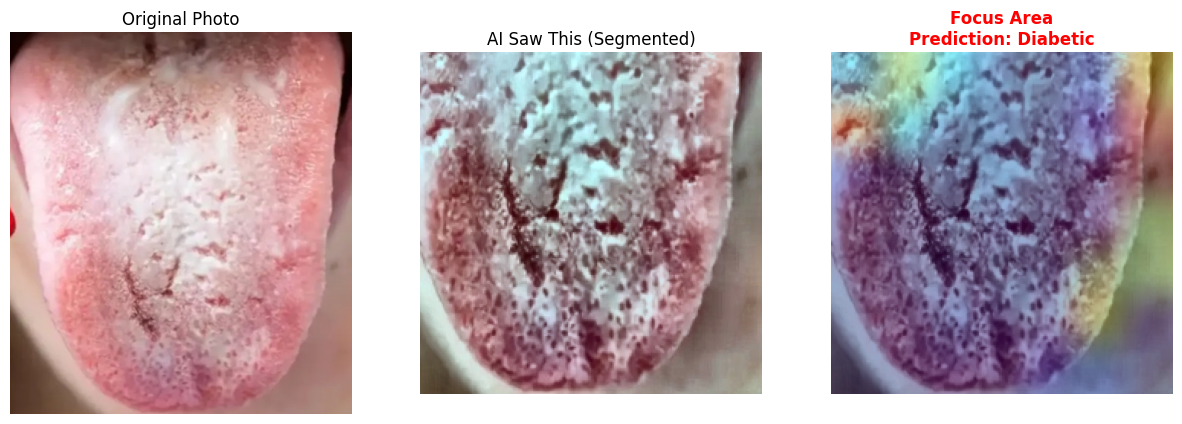

In [56]:
# Cell 14: Explain Specific Image
import numpy as np
import tensorflow as tf
import cv2
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import os

# --- 1. Grad-CAM Function ---
def make_heatmap(img_array, model, last_conv_layer_name="out_relu"):
    grad_model = tf.keras.models.Model(
        [model.inputs],
        [model.get_layer(last_conv_layer_name).output, model.output]
    )

    with tf.GradientTape() as tape:
        last_conv_layer_output, preds = grad_model(img_array)
        pred_index = tf.argmax(preds[0])
        class_channel = preds[:, pred_index]

    grads = tape.gradient(class_channel, last_conv_layer_output)
    pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))
    last_conv_layer_output = last_conv_layer_output[0]
    heatmap = last_conv_layer_output @ pooled_grads[..., tf.newaxis]
    heatmap = tf.squeeze(heatmap)
    heatmap = tf.maximum(heatmap, 0) / tf.math.reduce_max(heatmap)
    return heatmap.numpy()

# --- 2. Main Explanation Logic ---
def explain_single_image(image_path):
    # Verify path
    if not os.path.exists(image_path):
        print(f"❌ Error: File not found at {image_path}")
        return

    # Load Model
    # Note: If you renamed your model file, update this path!
    model_path = '/content/drive/MyDrive/best_diabetes_model.keras'
    try:
        model = tf.keras.models.load_model(model_path)
    except:
        print("❌ Error: Model file not found. Check Drive path.")
        return

    # Preprocess
    processor = TonguePreprocessor() # Uses class from Cell 3

    # Read Image
    original = cv2.imread(image_path)
    if original is None:
        print("❌ Error: Image is unreadable.")
        return
    original_rgb = cv2.cvtColor(original, cv2.COLOR_BGR2RGB)

    # Process for AI
    processed = processor.process_image(original_rgb)
    img_array = np.expand_dims(processed, axis=0)

    # Predict
    prediction = model.predict(img_array, verbose=0)[0][0]

    # Interpret
    # Assumes 0=Diabetic, 1=Non-Diabetic (Check your training labels!)
    if prediction < 0.5:
        label = "Diabetic"
        confidence = 1 - prediction
        color = 'red'
    else:
        label = "Non-Diabetic"
        confidence = prediction
        color = 'green'

    print(f"\n🔎 Result: {label}")
    print(f"📊 Raw Score: {prediction:.4f} (0=Diabetic, 1=Healthy)")

    # Generate Heatmap
    heatmap = make_heatmap(img_array, model, "out_relu")

    # Superimpose
    heatmap = np.uint8(255 * heatmap)
    jet = cm.get_cmap("jet")
    jet_colors = jet(np.arange(256))[:, :3]
    jet_heatmap = jet_colors[heatmap]

    jet_heatmap = tf.keras.preprocessing.image.array_to_img(jet_heatmap)
    jet_heatmap = jet_heatmap.resize((224, 224))
    jet_heatmap = tf.keras.preprocessing.image.img_to_array(jet_heatmap)

    # Rescale processed image to 0-255
    display_img = (processed + 1) * 127.5

    superimposed = jet_heatmap * 0.4 + display_img
    superimposed = tf.keras.preprocessing.image.array_to_img(superimposed)

    # Plot
    plt.figure(figsize=(15, 5))

    # 1. Original
    plt.subplot(1, 3, 1)
    plt.imshow(original_rgb)
    plt.title("Original Photo")
    plt.axis('off')

    # 2. AI Input
    plt.subplot(1, 3, 2)
    plt.imshow(tf.keras.preprocessing.image.array_to_img(display_img))
    plt.title("AI Saw This (Segmented)")
    plt.axis('off')

    # 3. Focus Area
    plt.subplot(1, 3, 3)
    plt.imshow(superimposed)
    plt.title(f"Focus Area\nPrediction: {label}", color=color, fontweight='bold')
    plt.axis('off')

    plt.show()

# === EXECUTE ===
test_image_path = '/content/drive/MyDrive/DataSet/RealTest/web_D2.jpg'
explain_single_image(test_image_path)